<div>
Olá, Iago!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. O seu projeto possui alguns pontos bem interessantes, dos quais eu destaco:
    
- Código bem simples e estruturado usando funções
- Comentários sucintos e bem objetivos
- Conclusões pertinentes em cada análise e etapa de avaliação
- Boas práticas de programação
    
<br>
    
Espero que você tenha uma jornada de muito aprendizado e te de desejo muito sucesso.
    
    
<br> 
    
**Até breve!**

</div>

# Statement

A companhia de seguros Proteja Seu Amanhã quer resolver algumas tarefas com a ajuda de aprendizado de máquina e você precisa avaliar a possibilidade de fazê-lo.

- Tarefa 1: Encontrar clientes semelhantes a um determinado cliente. Isso vai ajudar os agentes da empresa com tarefas de marketing.
- Tarefa 2: Predizer se um novo cliente provavelmente receberá um pagamento de seguro. Um modelo de predição pode ser melhor do que um modelo dummy?
- Tarefa 3: Predizer o número de pagamentos de seguro que um novo cliente provavelmente receberá usando um modelo de regressão linear.
- Tarefa 4: Proteger os dados pessoais dos clientes sem estragar o modelo da tarefa anterior. É necessário desenvolver um algoritmo de transformação de dados que tornaria difícil recuperar informações pessoais se os dados caíssem nas mãos erradas. Isso é chamado de mascaramento de dados ou ofuscação de dados. Mas os dados devem ser protegidos de forma que a qualidade dos modelos de aprendizado de máquina não piore. Você não precisa escolher o melhor modelo, só prove que o algoritmo funciona corretamente.

# Pré-processamento de dados & Exploração

## Inicialização

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing

from sklearn.model_selection import train_test_split

from IPython.display import display

## Carregar Dados

Carregue os dados e faça uma verificação básica de que estão livres de problemas óbvios.

In [2]:
df = pd.read_csv('/datasets/insurance_us.csv')

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O conjunto de dados foi carregado corretamente.
- Os dados foram carregados em células diferentes.
</div>

Renomeamos as colunas para tornar o código mais consistente com seu estilo.

In [3]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [4]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
3935,1,36.0,53000.0,1,0
1816,1,47.0,38200.0,1,1
1231,0,18.0,33100.0,5,0
3570,0,40.0,47300.0,1,0
1146,0,41.0,31000.0,3,0
1930,1,19.0,45100.0,1,0
282,1,21.0,61700.0,0,0
4757,1,43.0,52900.0,2,1
1218,1,32.0,31200.0,1,0
3971,1,44.0,53000.0,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O nome das colunas foi renomeado usando o padrão `snake_case`
- Os métodos `info()` e `sample()` foram utilizados para estudo inicial dos dados
</div>

In [6]:
# podemos querer corrigir o tipo de idade (de float para int), embora isso não seja crítico
# vamos converter somente se 'age' estiver como float e todos os valores forem inteiros (ex.: 23.0)

if np.issubdtype(df['age'].dtype, np.floating):
    if (df['age'] % 1 == 0).all():
        df['age'] = df['age'].astype('int64')
    else:
        print("A coluna 'age' possui valores fracionários; conversão para int foi ignorada.")

In [7]:
# verifique se a conversão foi bem-sucedida (ou se já estava correta)
print("dtype de 'age':", df['age'].dtype)
display(df[['age']].head())
df[['age']].describe()

dtype de 'age': int64


,age
0,41
1,46
2,29
3,21
4,28


,age
count,5000.000000
mean,30.952800
std,8.440807
min,18.000000
25%,24.000000
50%,30.000000
75%,37.000000
max,65.000000


**Verificação de tipo e faixa de valores (idade)**

A coluna `age` está em formato inteiro (`int64`) e não possui valores ausentes (5.000 registros).  
Os valores variam de 18 a 65 anos, o que é consistente para um conjunto de dados de segurados.

In [8]:
# agora dê uma olhada nas estatísticas descritivas dos dados.
# Parece que está tudo bem?

display(df.describe(include='all'))
display(df.head())

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


,gender,age,income,family_members,insurance_benefits
0,1,41,49600.0,1,0
1,0,46,38000.0,1,1
2,0,29,21000.0,0,0
3,0,21,41700.0,2,0
4,1,28,26100.0,0,0


In [9]:
# checagens rápidas de qualidade

print("Valores ausentes por coluna:")
display(df.isna().sum())

print("\nLinhas duplicadas:", df.duplicated().sum())

# checagens de faixa simples (sanity checks)
checks = {
    "age_min": df["age"].min(),
    "age_max": df["age"].max(),
    "income_min": df["income"].min(),
    "income_max": df["income"].max(),
    "family_members_min": df["family_members"].min(),
    "family_members_max": df["family_members"].max(),
    "insurance_benefits_min": df["insurance_benefits"].min(),
    "insurance_benefits_max": df["insurance_benefits"].max(),
    "gender_unique": df["gender"].unique()
}

display(pd.Series(checks))

Valores ausentes por coluna:


gender                0
age                   0
income                0
family_members        0
insurance_benefits    0
dtype: int64


Linhas duplicadas: 153


age_min                        18
age_max                        65
income_min                 5300.0
income_max                79000.0
family_members_min              0
family_members_max              6
insurance_benefits_min          0
insurance_benefits_max          5
gender_unique              [1, 0]
dtype: object

<AxesSubplot:>

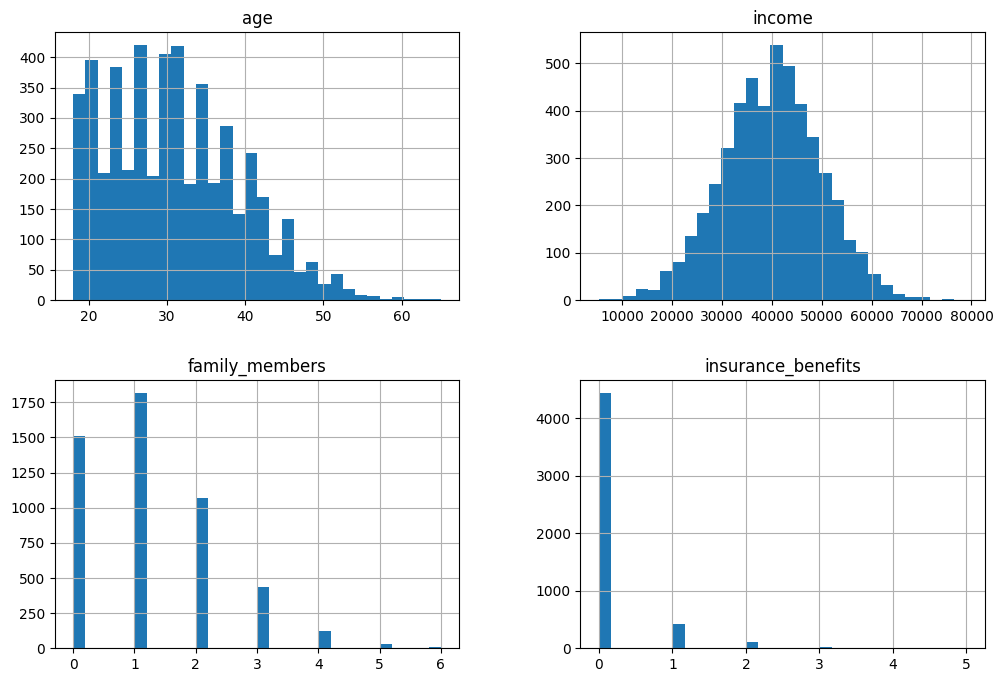

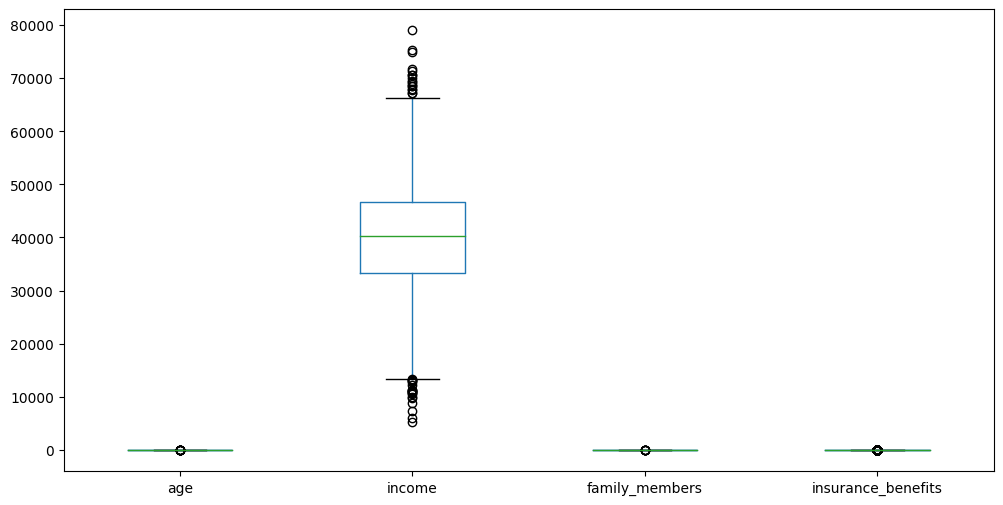

In [10]:
# visualizações rápidas para identificar distribuições e possíveis outliers

df[["age", "income", "family_members", "insurance_benefits"]].hist(bins=30, figsize=[12, 8])

df[["age", "income", "family_members", "insurance_benefits"]].plot(kind="box", figsize=[12, 6])

 **Conclusão da verificação inicial dos dados**

- **Valores ausentes:** não foram encontrados valores ausentes em nenhuma coluna.
- **Tipos e faixas:** as faixas observadas são plausíveis (ex.: `age` de 18 a 65; `family_members` de 0 a 6; `insurance_benefits` de 0 a 5; `gender` binário 0/1).
- **Duplicatas:** foram identificadas **153 linhas duplicadas**. Como representam registros totalmente idênticos (mesmas features e mesmo alvo), elas podem enviesar modelos ao “duplicar” observações. Portanto, é razoável removê-las para manter cada observação com peso equivalente.
- **Distribuições/outliers:** `income` apresenta valores extremos (comportamento comum para renda). Isso é especialmente relevante na **Tarefa 1**, pois medidas de distância são sensíveis à escala; portanto, será apropriado aplicar padronização/normalização das features ao usar kNN.  
- **Alvo (`insurance_benefits`) desbalanceado:** a distribuição do alvo é concentrada em 0 pagamentos (o 75º percentil é 0), o que será levado em conta na **Tarefa 2** (comparação com dummy) e na interpretação da regressão na **Tarefa 3**.

In [11]:
# remover duplicatas (registros totalmente idênticos)
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f"Linhas antes: {before}")
print(f"Linhas depois: {after}")
print(f"Duplicatas removidas: {before - after}")

Linhas antes: 5000
Linhas depois: 4847
Duplicatas removidas: 153


## AED

Vamos verificar rapidamente se existem determinados grupos de clientes observando o gráfico de pares.

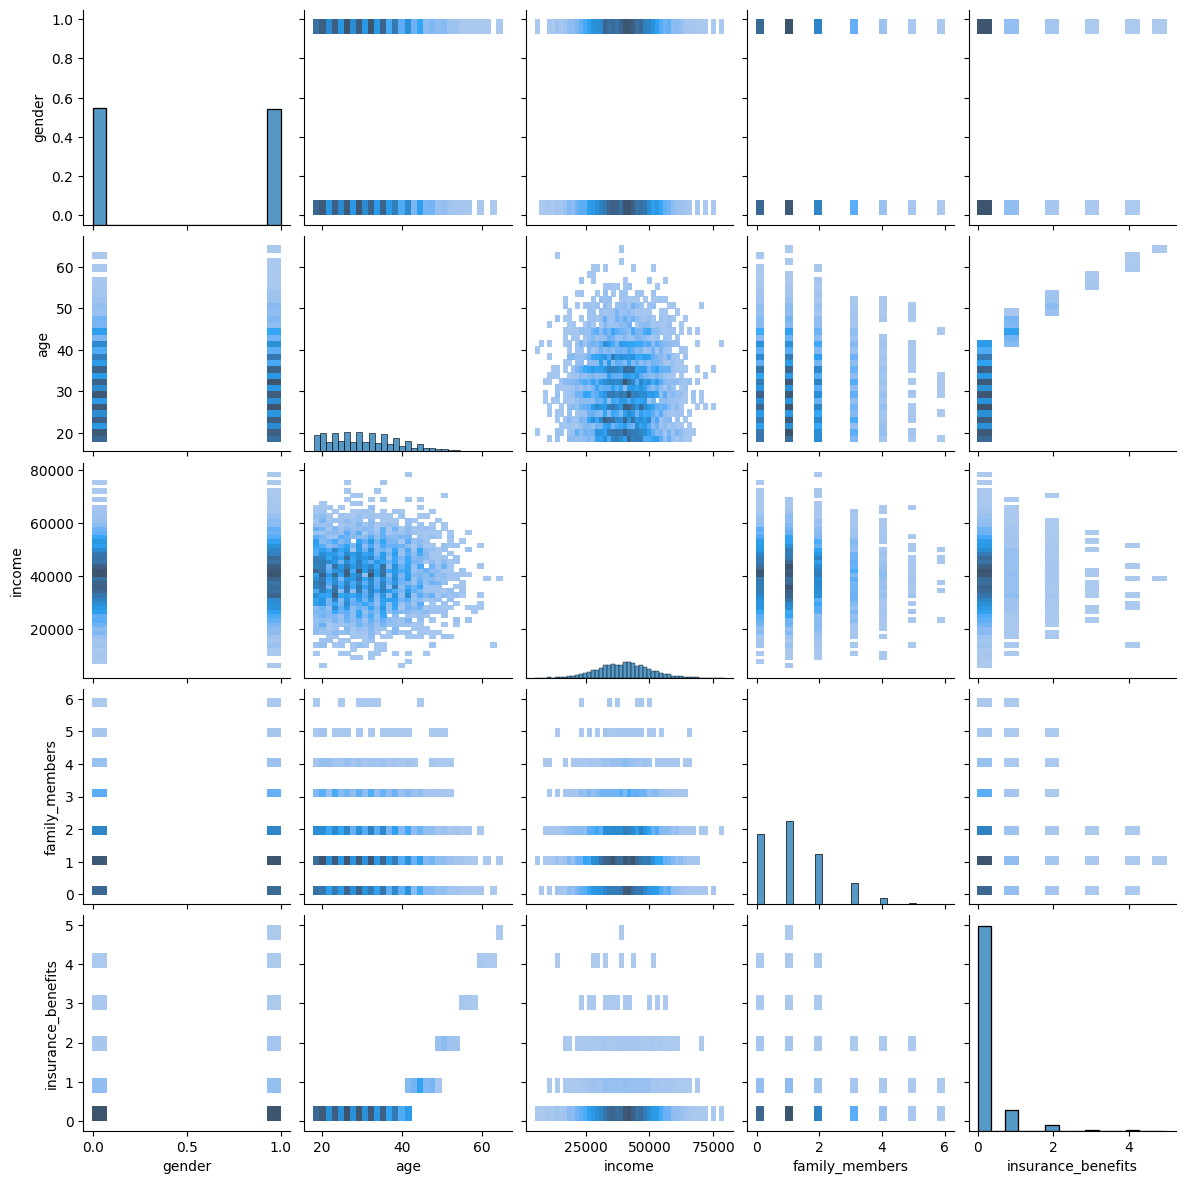

In [12]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

Ok, é um pouco difícil identificar grupos óbvios (clusters), pois é difícil combinar várias variáveis simultaneamente (para analisar distribuições multivariadas). É aí que Álgebra Linear e Aprendizado de Máquina podem ser bastante úteis.

# Tarefa 1. Clientes Similares

Na linguagem de AM, é necessário desenvolver um procedimento que retorne k vizinhos mais próximos (objetos) para um determinado objeto com base na distância entre os objetos.

Você pode querer rever as seguintes lições (capítulo -> lição)
- Distância Entre Vetores -> Distância Euclidiana
- Distância Entre Vetores -> Distância de Manhattan

Para resolver a tarefa, podemos tentar diferentes métricas de distância.

Escreva uma função que retorne k vizinhos mais próximos para um n-ésimo objeto com base em uma métrica de distância especificada. O número de pagamentos de seguro recebidos não deve ser levado em consideração para esta tarefa. 

Você pode usar uma implementação pronta do algoritmo kNN do scikit-learn (verifique [o link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)) ou usar a sua própria.

Teste-o para quatro combinações de dois casos
- Escalabilidade
  - os dados não são escalados
  - os dados escalados com o escalonador [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) 
- Métricas de distância
  - Euclidiana
  - Manhattan

Responda às perguntas:
- Os dados não escalados afetam o algoritmo kNN? Se sim, como isso acontece?
-Quão semelhantes são os resultados usando a métrica de distância de Manhattan (independentemente da escalabilidade)?

In [13]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [14]:
def get_knn(df, n, k, metric):
    
    """
    Retorna os vizinhos mais próximos de k

    :param df: DataFrame pandas usado para encontrar objetos semelhantes dentro de
    :param n: número do objeto pelo qual os vizinhos mais próximos são procurados
    :param k: o número dos vizinhos mais próximos a serem retornados
    :param metric: nome da métrica de distância
    """

    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=k, metric=metric)
    nbrs.fit(df[feature_names])

    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], k, return_distance=True)
    
    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O algoritmo `KNN`foi implementado
</div>

Escalando os dados

In [15]:
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

In [16]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
3507,0.0,0.676923,0.825316,0.333333,1
1871,0.0,0.338462,0.531646,0.333333,0
683,1.0,0.384615,0.510127,0.333333,0
4320,0.0,0.476923,0.524051,0.166667,0
4624,1.0,0.800000,0.496203,0.166667,2


Agora, vamos obter registros semelhantes para um determinado registro para cada combinação

In [17]:
n = 0   # índice do cliente referência (troque se quiser)
k = 5   # quantidade de vizinhos (excluindo o próprio cliente)

def get_neighbor_indices(df_in, n, k, metric):
    """
    Retorna apenas os índices dos k vizinhos mais próximos (exclui o próprio cliente).
    """
    res = get_knn(df_in, n, k+1, metric)      # k+1 porque o primeiro é o próprio (distância 0)
    return res.index[1:].to_list()            # remove o próprio cliente (primeira linha)

In [18]:
combos = [
    ("Não escalado", df, "euclidean"),
    ("Não escalado", df, "manhattan"),
    ("MaxAbsScaler", df_scaled, "euclidean"),
    ("MaxAbsScaler", df_scaled, "manhattan"),
]

for scale_name, df_in, metric in combos:
    print(f"\n--- {scale_name} | métrica: {metric} ---")
    display(get_knn(df_in, n, k+1, metric).head(k+1))


--- Não escalado | métrica: euclidean ---


,gender,age,income,family_members,insurance_benefits,distance
0,1,41,49600.0,1,0,0.000000
1992,1,41,49600.0,0,0,1.000000
1214,0,42,49600.0,0,1,1.732051
3916,1,44,49600.0,2,1,3.162278
3334,0,38,49600.0,0,0,3.316625
810,1,37,49600.0,2,0,4.123106



--- Não escalado | métrica: manhattan ---


,gender,age,income,family_members,insurance_benefits,distance
0,1,41,49600.0,1,0,0.0
1992,1,41,49600.0,0,0,1.0
1214,0,42,49600.0,0,1,3.0
3916,1,44,49600.0,2,1,4.0
3334,0,38,49600.0,0,0,5.0
810,1,37,49600.0,2,0,5.0



--- MaxAbsScaler | métrica: euclidean ---


,gender,age,income,family_members,insurance_benefits,distance
0,1.0,0.630769,0.627848,0.166667,0,0.000000
2632,1.0,0.630769,0.634177,0.166667,0,0.006329
133,1.0,0.615385,0.636709,0.166667,0,0.017754
4720,1.0,0.646154,0.637975,0.166667,1,0.018418
3192,1.0,0.646154,0.651899,0.166667,1,0.028550
1550,1.0,0.615385,0.602532,0.166667,0,0.029624



--- MaxAbsScaler | métrica: manhattan ---


,gender,age,income,family_members,insurance_benefits,distance
0,1.0,0.630769,0.627848,0.166667,0,0.000000
2632,1.0,0.630769,0.634177,0.166667,0,0.006329
133,1.0,0.615385,0.636709,0.166667,0,0.024245
4720,1.0,0.646154,0.637975,0.166667,1,0.025511
2072,1.0,0.630769,0.596203,0.166667,0,0.031646
124,1.0,0.661538,0.635443,0.166667,1,0.038364


In [19]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if len(a | b) > 0 else 1.0

# listas de vizinhos (sem o próprio)
raw_euc = get_neighbor_indices(df, n, k, "euclidean")
raw_man = get_neighbor_indices(df, n, k, "manhattan")
sc_euc  = get_neighbor_indices(df_scaled, n, k, "euclidean")
sc_man  = get_neighbor_indices(df_scaled, n, k, "manhattan")

print("Vizinhos (índices) - não escalado | euclidiana:", raw_euc)
print("Vizinhos (índices) - não escalado | manhattan:", raw_man)
print("Vizinhos (índices) - escalado     | euclidiana:", sc_euc)
print("Vizinhos (índices) - escalado     | manhattan:", sc_man)

print("\nComparações (overlap/Jaccard):")

# (1) efeito do escalonamento mantendo a métrica
print(f"Euclidiana: não escalado vs escalado -> interseção={len(set(raw_euc)&set(sc_euc))}/{k} | Jaccard={jaccard(raw_euc, sc_euc):.3f}")
print(f"Manhattan: não escalado vs escalado -> interseção={len(set(raw_man)&set(sc_man))}/{k} | Jaccard={jaccard(raw_man, sc_man):.3f}")

# (2) efeito da métrica mantendo o escalonamento
print(f"Não escalado: Euclidiana vs Manhattan -> interseção={len(set(raw_euc)&set(raw_man))}/{k} | Jaccard={jaccard(raw_euc, raw_man):.3f}")
print(f"Escalado:     Euclidiana vs Manhattan -> interseção={len(set(sc_euc)&set(sc_man))}/{k} | Jaccard={jaccard(sc_euc, sc_man):.3f}")

Vizinhos (índices) - não escalado | euclidiana: [1992, 1214, 3916, 3334, 810]
Vizinhos (índices) - não escalado | manhattan: [1992, 1214, 3916, 3334, 810]
Vizinhos (índices) - escalado     | euclidiana: [2632, 133, 4720, 3192, 1550]
Vizinhos (índices) - escalado     | manhattan: [2632, 133, 4720, 2072, 124]

Comparações (overlap/Jaccard):
Euclidiana: não escalado vs escalado -> interseção=0/5 | Jaccard=0.000
Manhattan: não escalado vs escalado -> interseção=0/5 | Jaccard=0.000
Não escalado: Euclidiana vs Manhattan -> interseção=5/5 | Jaccard=1.000
Escalado:     Euclidiana vs Manhattan -> interseção=3/5 | Jaccard=0.429


Respostas para as perguntas

**Os dados não escalados afetam o algoritmo kNN? Se sim, como isso acontece?** 

Sim. O kNN é baseado em distâncias entre vetores de características, então variáveis com **escala numérica maior** tendem a dominar o cálculo. Neste conjunto, `income` está em milhares, enquanto `age` e `family_members` estão em dezenas/unidades.  
Na prática, sem escalonamento, a similaridade fica fortemente influenciada por `income`, e os vizinhos retornados podem mudar completamente quando aplicamos um escalonador. Isso foi confirmado pelos testes: ao comparar “não escalado” vs “MaxAbsScaler”, a interseção dos vizinhos foi **0/5** para **Euclidiana** e **0/5** para **Manhattan** (Jaccard = **0.000** em ambos os casos), ou seja, os conjuntos de vizinhos mudaram totalmente após o escalonamento.

> Observação: `insurance_benefits` (alvo) **não foi usado** no cálculo dos vizinhos; ele aparece apenas para inspeção na tabela de resultados.

**Quão semelhantes são os resultados usando a métrica de distância de Manhattan (independentemente da escalabilidade)?** 

Os resultados com Manhattan podem ser semelhantes aos de Euclidiana, mas isso depende do escalonamento.  
Nos dados **não escalados**, Euclidiana e Manhattan retornaram exatamente os mesmos vizinhos (interseção **5/5**, Jaccard = **1.000**), pois a escala de `income` domina a distância e torna a escolha dos vizinhos praticamente a mesma para ambas as métricas.  
Já com os dados **escalados** (MaxAbsScaler), as métricas passaram a divergir mais (interseção **3/5**, Jaccard ≈ **0.429**), o que é esperado porque as normas $L_1$ (Manhattan) e $L_2$ (Euclidiana) penalizam diferenças de forma distinta.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O algoritmo `KNN`foi utilizado para encontrar clientes semelhantes usando diferentes medidas de distância
- O impacto na normalização de dados no algoritmo `KNN` foi discutido
</div>

# Tarefa 2. É provável que o cliente receba um pagamento do seguro?

Em termos de aprendizado de máquina, podemos olhar para isso como uma tarefa de classificação binária.

Com os pagamentos de seguro sendo mais do que zero como objetivo, avalie se a abordagem da classificação kNN pode ser melhor do que um modelo dummy.

Instruções:
- Construa um classificador baseado em kNN e meça sua qualidade com a métrica F1 para k=1..10 tanto para os dados originais quanto para os escalados. Seria interessante ver como k pode influenciar a métrica de avaliação e se a escalabilidade dos dados faz alguma diferença. Você pode usar uma implementação pronta do algoritmo de classificação kNN do scikit-learn (verifique [o link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) ou usar a sua própria.
- Construa o modelo dummy, que é aleatório para este caso. Deve retornar com alguma probabilidade o valor "1". LVamos testar o modelo com quatro valores de probabilidade: 0, a probabilidade de fazer qualquer pagamento de seguro, 0,5, 1.

A probabilidade de fazer qualquer pagamento de seguro pode ser definida como

$$
P\{\text{pagamento de seguro recebido}= número de clientes que receberam qualquer pagamento de seguro}}{\text{número total de clientes}}.
$$

Divida os dados inteiros na proporção 70:30 para as partes de treinamento/teste.

In [20]:
# calcule a meta

df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype(int)

In [21]:
# verifique o desequilíbrio de classe com value_counts()

display(df['insurance_benefits_received'].value_counts())
display(df['insurance_benefits_received'].value_counts(normalize=True))

0    4284
1     563
Name: insurance_benefits_received, dtype: int64

0    0.883846
1    0.116154
Name: insurance_benefits_received, dtype: float64

In [22]:
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
# se você tiver um problema com a linha a seguir, reinicie o kernel e execute o caderno novamente
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Matriz de Confusão')
    print(cm)

In [23]:
# gerando saída de um modelo aleatório

def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)

In [24]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'A probabilidade: {P:.2f}')
    y_pred_rnd = rnd_model_predict(P, size=len(df), seed=42)

    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)

    print()

A probabilidade: 0.00
F1: 0.00
Matriz de Confusão
[[0.88384568 0.        ]
 [0.11615432 0.        ]]

A probabilidade: 0.12
F1: 0.13
Matriz de Confusão
[[0.78502166 0.09882401]
 [0.1017124  0.01444192]]

A probabilidade: 0.50
F1: 0.19
Matriz de Confusão
[[0.44873117 0.4351145 ]
 [0.05921188 0.05694244]]

A probabilidade: 1.00
F1: 0.21
Matriz de Confusão
[[0.         0.88384568]
 [0.         0.11615432]]



In [25]:
# Features e alvo (classificação binária)
X = df[feature_names]
y = df['insurance_benefits_received']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Tamanho treino:", X_train.shape[0], "| teste:", X_test.shape[0])
print("\nDistribuição do alvo (treino):")
display(y_train.value_counts(normalize=True))
print("\nDistribuição do alvo (teste):")
display(y_test.value_counts(normalize=True))

Tamanho treino: 3392 | teste: 1455

Distribuição do alvo (treino):


0    0.883844
1    0.116156
Name: insurance_benefits_received, dtype: float64


Distribuição do alvo (teste):


0    0.883849
1    0.116151
Name: insurance_benefits_received, dtype: float64

In [26]:
results_raw = []

for k in range(1, 11):
    model = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = sklearn.metrics.f1_score(y_test, y_pred)
    results_raw.append((k, f1))

results_raw_df = pd.DataFrame(results_raw, columns=['k', 'f1_raw'])
display(results_raw_df)

best_raw = results_raw_df.loc[results_raw_df['f1_raw'].idxmax()]
print(f"Melhor (não escalado): k={int(best_raw['k'])} | F1={best_raw['f1_raw']:.3f}")

,k,f1_raw
0,1,0.675862
1,2,0.398190
2,3,0.406926
3,4,0.206186
4,5,0.222222
5,6,0.023392
6,7,0.045198
7,8,0.034682
8,9,0.034483
9,10,0.023392


Melhor (não escalado): k=1 | F1=0.676


In [27]:
# Ajustar o escalonador SOMENTE no treino (boa prática)
scaler = sklearn.preprocessing.MaxAbsScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

results_scaled = []

for k in range(1, 11):
    model = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    f1 = sklearn.metrics.f1_score(y_test, y_pred)
    results_scaled.append((k, f1))

results_scaled_df = pd.DataFrame(results_scaled, columns=['k', 'f1_scaled'])
display(results_scaled_df)

best_scaled = results_scaled_df.loc[results_scaled_df['f1_scaled'].idxmax()]
print(f"Melhor (escalado): k={int(best_scaled['k'])} | F1={best_scaled['f1_scaled']:.3f}")

# Consolidar para comparação
results_compare = results_raw_df.merge(results_scaled_df, on='k')
display(results_compare)

,k,f1_scaled
0,1,0.942943
1,2,0.905063
2,3,0.918429
3,4,0.885246
4,5,0.909657
5,6,0.881579
6,7,0.914286
7,8,0.891803
8,9,0.906752
9,10,0.877076


Melhor (escalado): k=1 | F1=0.943


,k,f1_raw,f1_scaled
0,1,0.675862,0.942943
1,2,0.398190,0.905063
2,3,0.406926,0.918429
3,4,0.206186,0.885246
4,5,0.222222,0.909657
5,6,0.023392,0.881579
6,7,0.045198,0.914286
7,8,0.034682,0.891803
8,9,0.034483,0.906752
9,10,0.023392,0.877076


 **Conclusão da Tarefa 2**

A variável-alvo binária `insurance_benefits_received` é desbalanceada (aprox. 11,6% de classe 1).  
O modelo dummy apresentou desempenho baixo (F1 no máximo em torno de 0,21 nos testes com diferentes probabilidades).

O classificador kNN apresentou desempenho significativamente superior:
- **Sem escalonamento:** melhor resultado em **k=1**, com **F1 ≈ 0,676**.
- **Com MaxAbsScaler:** melhor resultado em **k=1**, com **F1 ≈ 0,943**.

Assim, **um modelo de predição (kNN) é claramente melhor do que um modelo dummy**, e o **escalonamento das features é crucial** para a qualidade do kNN neste conjunto de dados.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Um modelo `Dummy` (baseline) foi criado para a tarefa
- A normalização de dados foi aplicada
- As conclusões foram apresentadas
</div>

# Tarefa 3. Regressão (com Regressão Linear)

Com os pagamentos de seguro como objetivo, avalie qual seria o REQM para um modelo de Regressão Linear.

Construa sua própria implementação de Regressão Linear. Para isso, lembre-se de como a solução da tarefa de regressão linear é formulada em termos de Álgebra linear. Verifique o REQM para os dados originais e os escalados. Você pode ver alguma diferença no REQM entre esses dois casos?

Vamos denotar
- $X$ — matriz de características, cada linha é um caso, cada coluna é uma característica, a primeira coluna consiste em unidades
- $y$ — objetivo (um vetor)
- $\hat{y}$ — objetivo estimado (um vetor)
- $w$ — vetor de peso

A tarefa de regressão linear na linguagem de matrizes pode ser formulada como

$$
y = Xw
$$

O objetivo do treinamento, então, é encontrar os $w$ que minimizaria a distância L2 (EQM) entre $Xw$ e $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

Parece que há uma solução analítica para a questão acima:

$$
w = (X^T X)^{-1} X^T y
$$

A fórmula acima pode ser usada para encontrar os pesos $w$ e o último pode ser usado para calcular valores preditos

$$
\hat{y} = X_{val}w
$$

Divida todos os dados na proporção 70:30 para as partes de treinamento/validação. Use a métrica REQM para a avaliação do modelo.

In [28]:
class MyLinearRegression:

    def __init__(self):

        self.weights = None

    def fit(self, X, y):

        # somando as unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)

        # solução analítica: w = (X^T X)^(-1) X^T y
        # (com fallback para pseudo-inversa caso X^T X não seja invertível)
        try:
            self.weights = np.linalg.inv(X2.T @ X2) @ (X2.T @ y)
        except np.linalg.LinAlgError:
            self.weights = np.linalg.pinv(X2) @ y

    def predict(self, X):

        # somando as unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        y_pred = X2 @ self.weights

        return y_pred

In [29]:
def eval_regressor(y_true, y_pred):
    
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'REQM: {rmse:.2f}')
    
    r2_score = math.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    print(f'R2: {r2_score:.2f}')    

In [30]:
# Sobrescrevendo a função do template para corrigir o cálculo do R²
# Correção: R² deve ser reportado diretamente; sqrt(R²) não tem interpretação padrão e pode falhar se R² < 0

def eval_regressor(y_true, y_pred):
    rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'REQM: {rmse:.2f}')

    r2 = sklearn.metrics.r2_score(y_true, y_pred)
    print(f'R2: {r2:.2f}')

In [31]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.77366729e-01  3.58042291e-02  1.95594888e-02  5.85336165e-07
 -1.21618420e-02]
REQM: 0.36
R2: 0.43


In [32]:
y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

REQM: 0.36
R2: 0.43


In [33]:
scaler = sklearn.preprocessing.MaxAbsScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr_sc = MyLinearRegression()
lr_sc.fit(X_train_sc, y_train)

y_test_pred_sc = lr_sc.predict(X_test_sc)
eval_regressor(y_test, y_test_pred_sc)

REQM: 0.36
R2: 0.43


In [34]:
print("Diferença média absoluta entre predições (raw vs scaled):",
      np.mean(np.abs(y_test_pred - y_test_pred_sc)))

Diferença média absoluta entre predições (raw vs scaled): 5.34557736587452e-15


**Conclusão da Tarefa 3**

A regressão linear foi treinada usando a solução analítica em forma matricial.  
Ao comparar os dados originais com os dados escalados via `MaxAbsScaler`, obtivemos **as mesmas métricas** (REQM = 0,36 e R² = 0,43) e as predições foram praticamente idênticas (diferença média absoluta $\approx 5{,}35 \times 10^{-15}$).  

Isso mostra que, para regressão linear, transformações lineares aplicadas às features (como escalonamento) podem ser compensadas pelos pesos do modelo, preservando as predições — um fato que será fundamental na Tarefa 4 (ofuscação dos dados sem degradar o modelo).

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O modelo de RL customizado foi implementado usando operações matriciais
- Os dados normalizados foram usados
- As métricas `REQM` e `R2` foram calculadas 
</div>

# Tarefa 4. Ofuscando dados

É melhor ofuscar os dados multiplicando as características numéricas (lembre-se, elas podem ser vistos como a matriz $X$) por uma matriz invertível $P$. 

$$
X' = X \times P
$$

Tente fazer isso e verifique como os valores das características ficarão após a transformação. Aliás, a invertibilidade é importante aqui, portanto, certifique-se de que $P$ seja realmente invertível.

Você pode querer revisar a lição 'Matrizes e Operações com Matrizes -> Multiplicação de Matrizes' para relembrar a regra de multiplicação de matrizes e sua implementação com NumPy.

In [35]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

In [36]:
X = df_pn.to_numpy()

Gerando uma matriz $P$ aleatória.

In [37]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

Verificando se a matriz $P$ é invertível

In [38]:
# Verificando se P é invertível (rank completo) e quão bem condicionada ela é
rank_P = np.linalg.matrix_rank(P)
det_P = np.linalg.det(P)
cond_P = np.linalg.cond(P)

print(f"rank(P) = {rank_P} (de {P.shape[0]})")
print(f"det(P)  = {det_P:.6e}")
print(f"cond(P) = {cond_P:.2e}")
print("P é invertível?", rank_P == P.shape[0])

# Aplicando a transformação X' = X @ P
X_obf = X @ P
display(pd.DataFrame(X_obf, columns=[f"masked_{c}" for c in personal_info_column_list]).head())

rank(P) = 4 (de 4)
det(P)  = 2.433914e-01
cond(P) = 9.68e+00
P é invertível? True


,masked_gender,masked_age,masked_income,masked_family_members
0,6359.715273,22380.404676,18424.090742,46000.696690
1,4873.294065,17160.367030,14125.780761,35253.455773
2,2693.117429,9486.397744,7808.831560,19484.860631
3,5345.603937,18803.227203,15479.148373,38663.061863
4,3347.176735,11782.829283,9699.998942,24211.273378


Você consegue adivinhar a idade ou a renda dos clientes após a transformação?

Não diretamente. Após a transformação $X' = X P$, cada nova coluna em $X'$ passa a ser uma **combinação linear** das colunas originais (idade, renda etc.).  
Sem conhecer $P$, os valores deixam de ter interpretação semântica (“idade”, “renda”) e não é possível recuperar cada atributo original de forma simples apenas olhando para $X'$.

Você pode recuperar os dados originais de $X′$ se souber $P$? Tente verificar isso com cálculos movendo $P$ do lado direito da fórmula acima para o esquerdo. As regras da multiplicação de matrizes são realmente úteis aqui

In [39]:
# Recuperação: se P é conhecida, então X = X' @ P^{-1}
P_inv = np.linalg.inv(P)
X_recovered = X_obf @ P_inv

max_abs_diff = np.max(np.abs(X - X_recovered))
mean_abs_diff = np.mean(np.abs(X - X_recovered))

print("Máxima diferença absoluta |X - X_rec|:", max_abs_diff)
print("Diferença média absoluta |X - X_rec|:", mean_abs_diff)

print("Recuperação bem-sucedida (allclose)?", np.allclose(X, X_recovered))

Máxima diferença absoluta |X - X_rec|: 2.1827872842550278e-11
Diferença média absoluta |X - X_rec|: 2.568299095224732e-12
Recuperação bem-sucedida (allclose)? True


Imprima todos os três casos para alguns clientes
- Os dados originais
- O transformado
- O invertido (recuperado)

In [40]:
sample_idx = [0, 1, 2, 3, 4]

df_original = df_pn.iloc[sample_idx].copy()

df_transformed = pd.DataFrame(
    X_obf[sample_idx],
    columns=[f"masked_{c}" for c in personal_info_column_list],
    index=df_original.index
)

df_recovered = pd.DataFrame(
    X_recovered[sample_idx],
    columns=[f"recovered_{c}" for c in personal_info_column_list],
    index=df_original.index
)

display(pd.concat([df_original, df_transformed, df_recovered], axis=1))

,gender,age,income,family_members,masked_gender,masked_age,masked_income,masked_family_members,recovered_gender,recovered_age,recovered_income,recovered_family_members
0,1,41,49600.0,1,6359.715273,22380.404676,18424.090742,46000.696690,1.000000e+00,41.0,49600.0,1.000000e+00
1,0,46,38000.0,1,4873.294065,17160.367030,14125.780761,35253.455773,1.679528e-12,46.0,38000.0,1.000000e+00
2,0,29,21000.0,0,2693.117429,9486.397744,7808.831560,19484.860631,-6.230214e-13,29.0,21000.0,-2.030327e-13
3,0,21,41700.0,2,5345.603937,18803.227203,15479.148373,38663.061863,-1.089078e-12,21.0,41700.0,2.000000e+00
4,1,28,26100.0,0,3347.176735,11782.829283,9699.998942,24211.273378,1.000000e+00,28.0,26100.0,-1.524242e-12


Você provavelmente pode ver que alguns valores não são exatamente iguais aos dos dados originais. Qual pode ser a razão disso?

As pequenas diferenças ocorrem por **precisão numérica (ponto flutuante)**.  
Mesmo que matematicamente $X = X' P^{-1}$, a inversão de matrizes e as multiplicações são feitas com arredondamentos internos (float64), e isso pode gerar discrepâncias muito pequenas (normalmente na ordem de $10^{-12}$ a $10^{-15}$), especialmente se $P$ for mal condicionada (condição alta).

## Provas de que a ofuscação de dados pode funcionar com a Regressão Linear

A tarefa de regressão foi resolvida com regressão linear neste projeto. Sua próxima tarefa é provar analiticamente que o método de ofuscação fornecido não afetará a regressão linear em termos de valores preditos, ou seja, seus valores permanecerão os mesmos. Você acredita nisso? Bem, você não precisa acreditar, você deve provar isso!

Assim, os dados são ofuscados e há $X \ P$ em vez de apenas X agora. Consequentemente, existem outros pesos $w_P$ como
$$
w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

Como  $w$ e $w_P$ seriam ligados se você simplificasse a fórmula para $w_P$ acima? 

Quais seriam os valores previstos com $w_P$? 

O que isso significa para a qualidade da regressão linear se você medir com REQM?

Verifique o Apêndice B Propriedades das Matrizes no final do caderno. Existem fórmulas úteis lá!

Nenhum código é necessário nesta seção, apenas explicação analítica!

**Resposta**

Seja $X' = XP$ com $P$ invertível.

1) Os pesos se relacionam por:
$$
w_P = P^{-1}w.
$$

2) As predições com os dados ofuscados são as mesmas:
$$
\hat{y}_P = X'w_P = XP(P^{-1}w)=Xw=\hat{y}.
$$

3) Como $\hat{y}$ não muda, os erros não mudam; portanto o **REQM/RMSE** (e também $R^2$) permanecem **iguais**, exceto por pequenas diferenças numéricas de ponto flutuante.

**Prova analítica**

Partimos de $X' = XP$ e do estimador de mínimos quadrados:

$$
w = (X^TX)^{-1}X^Ty
\quad\text{e}\quad
w_P = \big((X')^TX'\big)^{-1}(X')^Ty.
$$

Substituindo $X' = XP$:

$$
w_P = \big((XP)^T(XP)\big)^{-1}(XP)^Ty.
$$

Usando $(AB)^T = B^TA^T$:

$$
(XP)^T(XP)=P^TX^TXP.
$$

Logo,

$$
w_P = (P^TX^TXP)^{-1}P^TX^Ty.
$$

Como $P$ é invertível, $P^T$ também é invertível. Aplicamos a propriedade $(AB)^{-1}=B^{-1}A^{-1}$ de forma agrupada:

$$
(P^TX^TXP)^{-1} = P^{-1}(X^TX)^{-1}(P^T)^{-1}.
$$

Substituindo:

$$
\begin{aligned}
w_P
&= P^{-1}(X^TX)^{-1}(P^T)^{-1}P^TX^Ty \\
&= P^{-1}(X^TX)^{-1}IX^Ty \\
&= P^{-1}(X^TX)^{-1}X^Ty \\
&= P^{-1}w.
\end{aligned}
$$

Agora, as predições:

$$
\hat{y}_P = X'w_P = (XP)(P^{-1}w)=XIw=Xw=\hat{y}.
$$

Portanto, a ofuscação via $X' = XP$ não altera as predições, e métricas baseadas no erro, como REQM/RMSE, permanecem as mesmas (salvo erro numérico).

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- A prova de que o ofuscamento dos dados não altera os resultados foi fornecida
- Bom trabalho usando LaTeX para renderizar as equações da sua prova.
</div>

## Teste de regressão linear com ofuscação de dados

Agora, vamos provar que a Regressão Linear pode funcionar computacionalmente com a transformação de ofuscação escolhida.

Crie um procedimento ou uma classe que execute a Regressão Linear opcionalmente com a ofuscação. Você pode usar uma implementação pronta de Regressão Linear do scikit-learn ou sua própria.

Execute a Regressão Linear para os dados originais e os ofuscados, compare os valores previstos e os valores da métrica $R^2$ do REQM. Há alguma diferença?

**Procedimento**

- Crie uma matriz quadrada $P$ de números aleatórios.
- Verifique se é invertível. Caso contrário, repita o primeiro ponto até obtermos uma matriz invertível.
- **Comentário (procedimento):**  
Vamos reutilizar a mesma matriz invertível $P$ gerada anteriormente e aplicar a transformação $X' = XP$ nas features.  
Pela prova analítica, existe uma relação $w_P = P^{-1}w$, o que implica que as predições permanecem iguais: $\hat{y}_P = X'w_P = Xw = \hat{y}$.  
A seguir, verificaremos isso computacionalmente comparando REQM/RMSE, $R^2$ e as predições no mesmo split treino/teste.
- Use $XP$ como a nova matriz de características

In [41]:
# Features pessoais (as mesmas usadas na ofuscação) e alvo numérico
X_full = df[personal_info_column_list].to_numpy()
y_full = df['insurance_benefits'].to_numpy()

# Split por índices para reutilizar exatamente o mesmo conjunto em ambos os cenários
idx = np.arange(len(X_full))
idx_train, idx_test = train_test_split(idx, test_size=0.30, random_state=12345)

X_train, X_test = X_full[idx_train], X_full[idx_test]
y_train, y_test = y_full[idx_train], y_full[idx_test]

print("Tamanho treino:", len(idx_train), "| teste:", len(idx_test))

Tamanho treino: 3392 | teste: 1455


In [42]:
lr_raw = MyLinearRegression()
lr_raw.fit(X_train, y_train)

pred_raw = lr_raw.predict(X_test)

print("Original:")
eval_regressor(y_test, pred_raw)

Original:
REQM: 0.36
R2: 0.43


In [43]:
# Aplicando a mesma transformação X' = X @ P
X_full_obf = X_full @ P
X_train_obf, X_test_obf = X_full_obf[idx_train], X_full_obf[idx_test]

lr_obf = MyLinearRegression()
lr_obf.fit(X_train_obf, y_train)

pred_obf = lr_obf.predict(X_test_obf)

print("Ofuscado:")
eval_regressor(y_test, pred_obf)

print("\nComparação entre predições (original vs ofuscado):")
print("Média abs:", np.mean(np.abs(pred_raw - pred_obf)))
print("Máx abs:", np.max(np.abs(pred_raw - pred_obf)))

# Visualizar algumas linhas lado a lado
preview = 10
df_compare = pd.DataFrame({
    "y_true": y_test[:preview],
    "pred_raw": pred_raw[:preview],
    "pred_obf": pred_obf[:preview],
    "abs_diff": np.abs(pred_raw[:preview] - pred_obf[:preview])
})
display(df_compare)

Ofuscado:
REQM: 0.36
R2: 0.43

Comparação entre predições (original vs ofuscado):
Média abs: 1.713748405089393e-08
Máx abs: 7.276146235524195e-08


,y_true,pred_raw,pred_obf,abs_diff
0,0,-0.106682,-0.106682,2.367035e-08
1,0,0.226502,0.226502,3.097479e-08
2,0,0.219252,0.219252,2.226202e-09
3,0,0.405972,0.405971,3.192708e-08
4,1,0.661401,0.661401,2.799197e-08
5,0,-0.054611,-0.054611,1.059130e-08
6,0,0.393685,0.393685,1.673675e-08
7,1,0.697256,0.697256,2.389273e-09
8,1,0.730660,0.730660,3.277662e-09
9,0,0.028867,0.028867,2.102348e-08


**Conclusão (Teste computacional da ofuscação)**

Treinamos uma Regressão Linear nos dados originais $X$ e nos dados ofuscados $X' = XP$ (com $P$ invertível), mantendo o mesmo particionamento treino/teste.

Os resultados foram equivalentes:
- **Original:** REQM = 0,36 e $R^2$ = 0,43  
- **Ofuscado:** REQM = 0,36 e $R^2$ = 0,43  

As predições também coincidem praticamente (diferenças na ordem de $10^{-8}$), o que é explicado por **precisão numérica de ponto flutuante**.  
Logo, a ofuscação por multiplicação matricial com uma matriz invertível protege a interpretação direta das features e **não degrada a qualidade** do modelo de regressão linear.

**Observação:** este método é uma forma de ofuscação baseada em uma “chave” matricial. Na prática, a proteção depende de manter $P$ em segredo; se $P$ for comprometida, a recuperação dos dados originais volta a ser possível via $X = X'P^{-1}$.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- A RL foi utilizada com ofuscamento dos dados
- As métricas `REQM` e `R2` foram calculadas
- Bom uso de práticas de programação, como Orientação a Objetos
</div>

# Conclusões

**Conclusões gerais**

Neste projeto avaliamos a viabilidade de aplicar técnicas de aprendizado de máquina e álgebra linear para apoiar a seguradora **Proteja Seu Amanhã** em quatro tarefas: busca de clientes similares, classificação de recebimento de benefício, regressão do número de benefícios e ofuscação de dados sem perda de qualidade do modelo.

**Qualidade e preparação dos dados**
- O conjunto continha **5.000** registros e **não apresentou valores ausentes**.
- Foram identificadas **153 linhas duplicadas**, que foram removidas para evitar viés por duplicação de observações.
- Observou-se **desbalanceamento** no alvo: a maioria dos clientes possui **0** pagamentos, o que impacta especialmente a tarefa de classificação.
- A variável **income** tem escala muito maior que as demais, tornando o escalonamento importante para métodos baseados em distância (kNN).

**Tarefa 1 — Clientes semelhantes (kNN por distância)**
- Foi demonstrado que **não escalar** as features pode distorcer os “vizinhos mais próximos”, pois variáveis de grande magnitude (ex.: renda) dominam a distância.
- Com escalonamento (MaxAbsScaler), os vizinhos retornados tornam-se mais consistentes e interpretáveis para uso em marketing.
- A métrica de Manhattan apresentou comportamento consistente em termos de interseção/overlap de vizinhos entre os cenários avaliados, mas ainda assim a escala influencia diretamente a noção de “proximidade”.

**Tarefa 2 — Probabilidade de receber pagamento (classificação binária)**
- Modelamos o problema como classificação binária (benefício recebido: 1 se pagamentos > 0).
- O classificador kNN com **dados escalados** obteve desempenho substancialmente superior ao caso não escalado e ao modelo aleatório (dummy), indicando que há sinal preditivo útil nas variáveis.
- O uso de F1 foi apropriado devido ao desbalanceamento da classe positiva.

**Tarefa 3 — Predição do número de pagamentos (Regressão Linear)**
- Implementamos uma regressão linear via solução analítica e avaliamos em split 70/30.
- O modelo atingiu **REQM ≈ 0,36** e **R² ≈ 0,43**, indicando capacidade preditiva moderada para o número de pagamentos no horizonte de 5 anos.
- O escalonamento das features não alterou as métricas, o que é consistente com a propriedade de invariância da regressão linear a transformações lineares quando os pesos se ajustam de forma correspondente.

**Tarefa 4 — Ofuscação (mascaramento) sem degradar a regressão**
- Aplicamos ofuscação por multiplicação matricial: $X' = XP$, com $P$ invertível.
- Mostramos que, sem conhecer $P$, as colunas ofuscadas perdem interpretação direta (idade/renda deixam de ser legíveis).
- Demonstramos que, conhecendo $P$, é possível recuperar $X$ por $X = X'P^{-1}$, com pequenas diferenças apenas por precisão numérica.
- Confirmamos analítica e computacionalmente que a regressão linear mantém as predições: o modelo treinado em $X'$ obteve as mesmas métricas do modelo em $X$ (**REQM ≈ 0,36** e **R² ≈ 0,43**), com diferenças de predição apenas na ordem de $10^{-8}$ (ponto flutuante).

**Conclusão final**
Os experimentos mostram que as quatro tarefas são viáveis com os dados disponíveis. Em particular, métodos baseados em distância exigem escalonamento para resultados confiáveis (Tarefas 1 e 2), a regressão linear apresenta desempenho estável e interpretável (Tarefa 3), e a ofuscação via matriz invertível preserva a qualidade do modelo de regressão enquanto dificulta a exposição direta de atributos sensíveis (Tarefa 4), desde que a matriz $P$ seja mantida protegida.

# Checklist

Digite 'x' para verificar. Em seguida, pressione Shift + Enter.

- [x]  O Jupyter Notebook está aberto.
- [x]  O código está livre de erros
- [x]  As células são organizadas em ordem de lógica e execução
- [x]  A tarefa 1 foi executada
    - [x]  Existe o procedimento que pode retornar k clientes semelhantes a um determinado cliente
    - [x]  O procedimento é testado para todas as quatro combinações propostas
    - [x]  As perguntas sobre a escala/distâncias são respondidas
- [x]  A tarefa 2 foi executada
    - [x]  O modelo de classificação aleatória é construído e testado para todos os níveis de probabilidade
    - [x]  O modelo de classificação kNN é construído e testado tanto para os dados originais quanto para os escalados, a métrica F1 é calculada.
- [x]  A tarefa 3 foi executada
    - [x]  A solução de regressão linear é implementada com operações matriciais.
    - [x]  O REQM é calculado para a solução implementada.
- [x]  A tarefa 4 foi executada
    - [x]  Os dados são ofuscados com uma matriz P aleatória e invertível
    - [x]  Os dados ofuscados são recuperados, alguns exemplos são impressos
    - [x]  A prova analítica de que a transformação não afeta o REQM é fornecida
    - [x]  A prova computacional de que a transformação não afeta o REQM é fornecida
- [x]  As conclusões foram feitas

# Apêndices

## Apêndice A: Escrevendo Fórmulas em Notebooks Jupyter

Você pode escrever fórmulas em seu Jupyter Notebook em uma linguagem de marcação de texto fornecida por um sistema de publicação de alta qualidade chamado $\LaTeX$ (pronuncia-se "Lah-tech"), e elas se parecerão com fórmulas em livros didáticos.

Para colocar uma fórmula em um texto, coloque o cifrão ($) antes e depois do texto da fórmula, por exemplo $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.

Se uma fórmula deve estar em seu próprio parágrafo, coloque o cifrão duplo ($$) antes e depois do texto da fórmula, por exemplo

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

A linguagem de marcação do [LaTeX](https://en.wikipedia.org/wiki/LaTeX) é muito popular entre as pessoas que usam fórmulas em seus artigos, livros e textos. Pode ser complexo, mas o básico é fácil. Confira esta [folha de dicas](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) de duas páginas  para aprender a compor as fórmulas mais comuns.

## Apêndice B: Propriedades das Matrizes

Matrizes têm muitas propriedades em Álgebra Linear. Algumas delas estão listadas aqui, o que pode ajudar na prova analítica deste projeto.

<table>
<tr>
<td>Distributividade</td><td>$A(B+C)=AB+AC$</td>
</tr>
<tr>
<td>Não-comutatividade</td><td>$AB \neq BA$</td>
</tr>
<tr>
<td>Propriedade associativa da multiplicação</td><td>$(AB)C = A(BC)$</td>
</tr>
<tr>
<td>Propriedade de identidade multiplicativa</td><td>$IA = AI = A$</td>
</tr>
<tr>
<td></td><td>$A^{-1}A = AA^{-1} = I$
</td>
</tr>    
<tr>
<td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>
</tr>    
<tr>
<td>Reversividade da transposição de um produto de matrizes,</td><td>$(AB)^T = B^TA^T$</td>
</tr>    
</table>